# Cuantización a int8 del modelo de grilla (dos salidas)

**Proyecto Final de Ingeniería en Electrónica — FaCENA-UNNE**
(Red de sensores LoRa para detección temprana de incendios)

Toma el modelo que entrena `6_red_grilla.ipynb` —un `.keras` funcional con **dos
salidas**: `salida` (2,) y `grilla` (4, 4, 2)— y produce lo que se compila en el nodo
ESP32-S3: un `.tflite` **full-int8** con **dos tensores de salida**, cada uno con su
propia escala y *zero point*.

Es el equivalente de `5_cuantizacion.ipynb` para el modelo de grilla. No modifica el
notebook 5 porque las diferencias son demasiadas: el `.keras` tiene otro prefijo, otra
firma de salida (dict vs tensor), necesita `compile=False` para cargarse, la evaluación
tiene que armar etiquetas por celda, y el umbral de grilla es independiente del de
imagen. Meter todo en el 5 con un `if` rompe la lectura sin ganar nada; un notebook
propio es más claro y cada uno se puede correr por separado sin riesgo de tomar el modelo
equivocado.

| Entra | Sale (en `salidas/modelos/`) |
|---|---|
| el `grilla4x4_fuego_*.keras` más reciente | `grilla_int8.tflite`, `grilla_int8.cc`, `cuantizacion_grilla.json` |

**Recorrido:** datos y modelo → exportación int8 → evaluación int8 y "como lo ve la
cámara" → umbral de decisión (imagen + grilla) → entregables.

## 1. Datos y modelo

Todo corre en **CPU**: ni la conversión ni el intérprete TFLite usan la GPU, y así este
notebook no depende de la cuDNN ni le disputa la memoria de la GTX 1050 a un
entrenamiento.

Los datos se arman con `modulos/dfire.py`, **el mismo módulo que usa el entrenamiento**:
la calibración int8 y la evaluación del modelo cuantizado tienen que ver las imágenes
preprocesadas exactamente como las vio la red al entrenar (reducción bilineal con
*antialias*, redondeo a uint8). Una diferencia ahí no rompe nada visible: corre los
rangos int8 y la exactitud cae en silencio.

Las etiquetas **por celda** salen de `dfire.tabla_cajas`, `dfire.mascara_cajas` y
`dfire.objetivos`: las mismas funciones que usa el notebook 6 para entrenar. No se
reimplementan.

La partición es la oficial del banco, y las métricas que valen son las del subconjunto
**sin gemelos** de entrenamiento, tanto en prueba como en validación (§6bis del
notebook 4). El modelo es el `.keras` más reciente que dejó el notebook 6.

In [1]:
import os

# Todo en CPU: la conversión y el intérprete TFLite no usan GPU, y así este notebook no
# depende de la cuDNN ni compite por la memoria de la GTX 1050 con un entrenamiento.
# Tiene que ir ANTES de importar TensorFlow.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from tensorflow import keras

MODULOS = Path("../modulos") if Path("../modulos").exists() else Path("modulos")
SALIDAS = MODULOS.parent / "salidas"        # misma raíz que `modulos/`
sys.path.insert(0, str(MODULOS.resolve()))
from dfire import (CLASES, COMBOS, IMG_SIZE, armar_ds, combo, indexar, leer_imagen,
                   mascara_cajas, objetivos, particion, sin_gemelo, tabla_cajas)

SEED = 42          # sólo ordena dentro de cada split; la pertenencia es la oficial
BATCH_SIZE = 32
GRILLA = 4         # tiene que coincidir con la grilla del modelo (4×4 en el notebook 6)
DATA_DIR = MODULOS.parent / "data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data"
assert DATA_DIR.exists(), f"no está el banco en {DATA_DIR}: correr antes 4.red_entrenada.ipynb"

print("TensorFlow:", tf.__version__, "| dispositivos:", tf.config.list_physical_devices())

I0000 00:00:1790103739.586639  193041 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0 | dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1790103742.552349  193041 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1790103742.552383  193041 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
I0000 00:00:1790103742.552391  193041 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
I0000 00:00:1790103742.552400  193041 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1790103742.552403  193041 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: fedora
I0000 00:00:1790103742.552407  193041 cuda_diagnostics.cc:183] hostname: fedora
I0000 00:00:1790103742.552471  193041 cuda_diagnostics.cc:190] libcuda reported version is: 580.178.4
I0000 00:00:1790103742.552490  193041 cuda_diagnostics.cc:194] kern

In [2]:
ARCHIVOS, ETIQUETAS, SPLITS = indexar(DATA_DIR)     # ETIQUETAS: (N, 2) [fuego, humo]
COMBO = combo(ETIQUETAS)
CAJAS = tabla_cajas(ARCHIVOS)                       # (N, K, 5) [canal, x0, y0, x1, y1]
particiones = particion(SPLITS, SEED)
idx_train, idx_val, idx_test = (particiones[s] for s in ("train", "val", "test"))

# Sin mezclar: las predicciones salen en el orden de idx_val / idx_test.
val_ds = armar_ds(ARCHIVOS[idx_val], ETIQUETAS[idx_val], BATCH_SIZE)
test_ds = armar_ds(ARCHIVOS[idx_test], ETIQUETAS[idx_test], BATCH_SIZE)
y_true = ETIQUETAS[idx_test]

# Etiquetas por celda de TODO el banco, sin aumento (las mismas que calcula el
# notebook 6 en §2: mascara_cajas + objetivos, definidos en dfire.py).
ds_cajas = (tf.data.Dataset.from_tensor_slices(CAJAS)
            .map(mascara_cajas, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(512))
grillas_list = []
for mascaras in ds_cajas:
    o = objetivos(mascaras, GRILLA)
    grillas_list.append(o["grilla"].numpy().astype(np.uint8))
GRILLAS = np.concatenate(grillas_list)                # (N, GRILLA, GRILLA, 2)
g_true = GRILLAS[idx_test]                            # etiquetas por celda de prueba

# Gemelos de entrenamiento (§6bis del notebook 4): prueba Y validación los tienen, y
# con ellos adentro los números salen optimistas. Train se hashea una sola vez.
LIMPIO = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_test])
LIMPIO_VAL = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_val])

print(f"train {len(idx_train)}   val {len(idx_val)}   test {len(idx_test)}")
print(f"sin gemelo en entrenamiento: prueba {LIMPIO.sum()} de {len(LIMPIO)}, "
      f"validación {LIMPIO_VAL.sum()} de {len(LIMPIO_VAL)}")

W0000 00:00:1790103745.720140  193154 cpu_allocator_impl.cc:82] Allocation of 37748736 exceeds 10% of free system memory.
W0000 00:00:1790103745.807340  193155 cpu_allocator_impl.cc:82] Allocation of 37748736 exceeds 10% of free system memory.
W0000 00:00:1790103745.915372  193155 cpu_allocator_impl.cc:82] Allocation of 37748736 exceeds 10% of free system memory.
W0000 00:00:1790103746.017364  193156 cpu_allocator_impl.cc:82] Allocation of 37748736 exceeds 10% of free system memory.
W0000 00:00:1790103746.126655  193154 cpu_allocator_impl.cc:82] Allocation of 37748736 exceeds 10% of free system memory.


train 14122   val 3099   test 4306
sin gemelo en entrenamiento: prueba 3320 de 4306, validación 2399 de 3099


In [3]:
# El `.keras` más reciente que dejó el notebook 6 (el nombre lleva la grilla y las épocas).
candidatos_keras = sorted(
    (SALIDAS / "modelos").glob(f"grilla{GRILLA}x{GRILLA}_fuego_*.keras"),
    key=lambda p: p.stat().st_mtime,
)
assert candidatos_keras, (
    f"no hay modelo de grilla {GRILLA}×{GRILLA}: correr antes 6_red_grilla.ipynb")
RUTA_KERAS = candidatos_keras[-1]

# compile=False: la pérdida de la grilla (`perdida_grilla`) es una función definida
# dentro del notebook 6, y Keras no la encuentra fuera de él.  Para cuantizar sólo
# necesitamos el forward: compile=False evita la búsqueda.
modelo_base = keras.models.load_model(RUTA_KERAS, compile=False)

# Verificar que la firma de salida es la esperada: dict con las dos claves.
assert isinstance(modelo_base.output, dict), (
    f"{RUTA_KERAS.name} no tiene salida dict: ¿es un modelo de una sola salida? "
    f"Usar 5_cuantizacion.ipynb en su lugar")
assert "salida" in modelo_base.output and "grilla" in modelo_base.output, (
    f"{RUTA_KERAS.name} no tiene las claves 'salida' y 'grilla': {list(modelo_base.output)}")
shape_salida = modelo_base.output["salida"].shape
shape_grilla = modelo_base.output["grilla"].shape
assert shape_salida[-1] == len(CLASES), (
    f"la salida tiene {shape_salida[-1]} clases y se esperan {len(CLASES)}")
assert shape_grilla[1:3] == (GRILLA, GRILLA), (
    f"la grilla es {shape_grilla[1:3]} y se espera ({GRILLA}, {GRILLA})")
print(f"modelo: {RUTA_KERAS.name}")
print(f"  salida: {shape_salida}   grilla: {shape_grilla}")

# Referencia float32: lo que el cuantizado tiene que igualar.
pred_f32 = modelo_base.predict(test_ds, verbose=0)
y_prob = pred_f32["salida"]                  # (N, 2): P(fuego), P(humo)
g_prob = pred_f32["grilla"]                  # (N, 4, 4, 2): por celda
y_pred = (y_prob >= 0.5).astype(np.uint8)
print(f"{len(y_prob)} imágenes de prueba evaluadas en float32")

modelo: grilla4x4_fuego_epochs_84_image_size_96x96.keras
  salida: (None, 2)   grilla: (None, 4, 4, 2)
4306 imágenes de prueba evaluadas en float32


## 2. Exportación a TFLite Micro (int8)

El mismo camino que el notebook 5 — SavedModel → `TFLiteConverter` con calibración — pero
el `.tflite` resultante tiene **dos tensores de salida**, cada uno con su propia escala y
*zero point* int8. El converter los crea automáticamente: el modelo funcional de Keras ya
expone las dos salidas.

1. **`modelo_base.export(..., format="tf_saved_model")`** — `TFLiteConverter.from_keras_model`
   no funciona con Keras 3; el camino válido es pasar por un SavedModel.
2. **`optimizations=[Optimize.DEFAULT]`** — activa la cuantización post-entrenamiento.
3. **`representative_dataset`** — calibra los rangos dinámicos con imágenes reales,
   estratificadas por combinación de etiquetas (igual que el notebook 5).
4. **`supported_ops=[TFLITE_BUILTINS_INT8]`** — sólo *builtins* int8, compatible con
   TFLite Micro.
5. **`inference_input_type/output_type = tf.int8`** — entrada y salidas ya son int8:
   el firmware no convierte nada.

Los parámetros de calibración son los mismos que en el notebook 5 (500 por combinación).
Si la caída de float a int8 supera ~2 puntos de recall, subir `N_REPRESENTATIVAS` es la
primera palanca.

In [4]:
# 500 por combinación: con 100 por clase, el modelo anterior de 3 clases perdía entre
# 3,7 y 5,7 puntos de recall de `humo` al pasar a int8 (ver PTQ, abajo). Más
# calibración es la palanca más barata: no toca el entrenamiento.
N_REPRESENTATIVAS = 500     # por combinación -> 2000 imágenes de TRAIN, nunca de test


def ds_representativo(n_por_clase=N_REPRESENTATIVAS):
    '''Imágenes de entrenamiento sin aumento, 0-255 float32, shape [1, 96, 96, 3].

    Leídas con `leer_imagen`, la misma función que arma los datos de entrenamiento: si
    la calibración viera otro preprocesamiento, los rangos int8 saldrían de otra
    distribución. Estratificado por combinación de etiquetas: si sólo entraran escenas
    diurnas, las nocturnas saturan en int8 y la exactitud se cae justo de noche.
    '''
    for c in range(len(COMBOS)):
        idx = idx_train[COMBO[idx_train] == c][:n_por_clase]
        for ruta in ARCHIVOS[idx]:
            yield [tf.expand_dims(tf.cast(leer_imagen(ruta), tf.float32), 0)]


print(f"{sum(1 for _ in ds_representativo())} imágenes representativas "
      f"({N_REPRESENTATIVAS} por combinación)")

2000 imágenes representativas (500 por combinación)


In [5]:
import tempfile

# El SavedModel es un paso intermedio del converter, no un entregable: vive lo que
# dura la conversión.
with tempfile.TemporaryDirectory() as tmp:
    modelo_base.export(tmp, format="tf_saved_model")

    conv = tf.lite.TFLiteConverter.from_saved_model(tmp)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = ds_representativo
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type = tf.int8
    conv.inference_output_type = tf.int8
    tflite = conv.convert()

print(f"modelo int8: {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")

INFO:tensorflow:Assets written to: /tmp/tmpqtfueks0/assets


INFO:tensorflow:Assets written to: /tmp/tmpqtfueks0/assets


Saved artifact at '/tmp/tmpqtfueks0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='entrada')
Output Type:
  Dict[['salida', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)], ['grilla', TensorSpec(shape=(None, 4, 4, 2), dtype=tf.float32, name=None)]]
Captures:
  139990616728656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616727888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616724240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992236388240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616728080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616732688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616729424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616730192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139990616725776: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1790103932.804470  193041 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790103932.804486  193041 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790103932.804791  193041 reader.cc:83] Reading SavedModel from: /tmp/tmpqtfueks0
I0000 00:00:1790103932.810959  193041 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790103932.810978  193041 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpqtfueks0
I0000 00:00:1790103932.863439  193041 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790103932.874667  193041 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790103933.233903  193041 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpqtfueks0
I0000 00:00:1790103933.334780  193041 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 529998 microseconds.
I0000 00:00:1790103933.443322  19304

modelo int8: 321584 bytes (314 kB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1790103953.511402  193041 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


### PTQ *full-int8*, sin QAT

La cuantización es **post-entrenamiento** (`Optimize.DEFAULT`), no *quantization-aware
training*: `tensorflow_model_optimization` todavía no soporta Keras 3. Si la caída de float
a int8 supera ~2 puntos de recall en una clase que dispara alerta —`fuego` **o `humo`**—,
las palancas son, en orden: más imágenes representativas, α=0.5 (796 kB de pesos, sigue
entrando en SRAM) o mirar qué capa concentra el error.

El modo de cuantización es **per-channel**: las convoluciones (incluidas las depthwise)
llevan su propia escala por canal de salida. Eso lo soporta `esp-tflite-micro` con
**ESP-NN**, que es el runtime del nodo. No se usa ESP-DL, que en el S3 cuantiza
per-tensor.

In [6]:
# Sin delegados: el intérprete de la PC usa XNNPACK por defecto y reportaría un DELEGATE
# que no existe en el firmware. Así se ven las ops reales del archivo.
interprete = tf.lite.Interpreter(
    model_content=tflite,
    experimental_op_resolver_type=(
        tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    ),
)
ops = sorted({d["op_name"] for d in interprete._get_ops_details()})
print(ops)

# Estas son las ops que hay que registrar en el firmware (ADD y MUL son el `Rescaling`
# plegado a int8; MAX_POOL_2D viene de la cabeza de grilla). Con esta lista se arma un
# MicroMutableOpResolver en vez de AllOpsResolver: decenas de kB menos de flash y de RAM.

['ADD', 'CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'LOGISTIC', 'MAX_POOL_2D', 'MEAN', 'MUL']


/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [7]:
import json

interprete.allocate_tensors()
det_entrada = interprete.get_input_details()[0]

# El modelo de grilla tiene DOS tensores de salida. El converter les asigna un índice
# que puede no coincidir con el orden de las claves del dict de Keras. Los identificamos
# por su forma: (1, 2) es `salida`, (1, 4, 4, 2) es `grilla`.
detalles_salida = interprete.get_output_details()
assert len(detalles_salida) == 2, (
    f"se esperan 2 tensores de salida, hay {len(detalles_salida)}")

det_salida = det_grilla = None
for d in detalles_salida:
    # La forma de `salida` es (1, 2); la de `grilla` es (1, 4, 4, 2).
    if len(d["shape"]) == 2:
        det_salida = d
    elif len(d["shape"]) == 4:
        det_grilla = d
assert det_salida is not None and det_grilla is not None, (
    f"no se pudo identificar salida y grilla: formas = {[d['shape'] for d in detalles_salida]}")
assert list(det_salida["shape"]) == [1, len(CLASES)], det_salida["shape"]
assert list(det_grilla["shape"]) == [1, GRILLA, GRILLA, len(CLASES)], det_grilla["shape"]

cuantizacion = {
    "entrada": {"scale": float(det_entrada["quantization"][0]),
                "zero_point": int(det_entrada["quantization"][1]),
                "shape": [int(d) for d in det_entrada["shape"]]},
    "salida": {"scale": float(det_salida["quantization"][0]),
               "zero_point": int(det_salida["quantization"][1]),
               "shape": [int(d) for d in det_salida["shape"]]},
    "grilla": {"scale": float(det_grilla["quantization"][0]),
               "zero_point": int(det_grilla["quantization"][1]),
               "shape": [int(d) for d in det_grilla["shape"]]},
    "etiquetas": CLASES,            # una sigmoide por etiqueta, independientes
    "bytes": len(tflite),
}

ruta_modelos = SALIDAS / "modelos"
ruta_modelos.mkdir(parents=True, exist_ok=True)
print(json.dumps(cuantizacion, indent=2))

{
  "entrada": {
    "scale": 1.0,
    "zero_point": -128,
    "shape": [
      1,
      96,
      96,
      3
    ]
  },
  "salida": {
    "scale": 0.00390625,
    "zero_point": -128,
    "shape": [
      1,
      2
    ]
  },
  "grilla": {
    "scale": 0.00390625,
    "zero_point": -128,
    "shape": [
      1,
      4,
      4,
      2
    ]
  },
  "etiquetas": [
    "fuego",
    "humo"
  ],
  "bytes": 321584
}


In [8]:
def a_c_array(datos, nombre="grilla_int8"):
    '''Array de C listo para compilar en el firmware.

    `alignas(16)`: TFLM exige alineación a 16 bytes para el buffer del modelo.
    `const`: manda el array a `.rodata`, o sea a flash, y no a RAM.
    '''
    lineas = [f"// Modelo TFLite int8 de {len(datos)} bytes — generado por 7_cuantizacion_grilla.ipynb",
              "#include <cstdint>",
              "",
              f"alignas(16) const unsigned char {nombre}[] = {{"]
    for i in range(0, len(datos), 12):
        lineas.append("    " + " ".join(f"0x{b:02x}," for b in datos[i:i + 12]))
    lineas.append("};")
    lineas.append(f"const unsigned int {nombre}_len = {len(datos)};")
    return "\n".join(lineas) + "\n"


(ruta_modelos / "grilla_int8.cc").write_text(a_c_array(tflite))
print(f"{ruta_modelos / 'grilla_int8.cc'}: {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")

../salidas/modelos/grilla_int8.cc: 321584 bytes (314 kB)


## 3. Evaluación del modelo int8 (y "como lo ve la cámara")

Al nodo va el `.tflite` int8, no el modelo de Keras: hay que medir **a él**. Se corre el
**mismo** `test_ds` (4306 imágenes, nunca vistas) con `tf.lite.Interpreter`: el mismo
archivo que va a correr el ESP32-S3, ejecutado acá en la PC.

Diferencia con el notebook 5: la predicción devuelve un dict con las dos salidas
decuantizadas, y las métricas se calculan para **las dos**:
- **Imagen**: recall y precisión de `fuego` y `humo`, como en el notebook 5.
- **Grilla**: recall y precisión **por celda**, y si la celda más probable cae en el
  lugar correcto.

Y una tercera pasada, la que más se parece al campo: D-Fire son fotos web de alta
resolución; el OV2640 entrega 96×96 en **RGB565** (5 bits de rojo, 6 de verde, 5 de azul).
Cuantizar el color a esa profundidad es el único número que predice el comportamiento real.

In [9]:
def predecir_int8(imagen):
    '''Imagen float32 0-255 (H, W, 3) -> {"salida": (2,), "grilla": (4, 4, 2)} float32.

    Cuantiza la entrada a int8 y decuantiza las DOS salidas.
    '''
    escala_e, zp_e = det_entrada["quantization"]
    x = np.clip(np.round(imagen / escala_e + zp_e), -128, 127).astype(np.int8)
    interprete.set_tensor(det_entrada["index"], x[None])
    interprete.invoke()

    # Salida de imagen
    escala_s, zp_s = det_salida["quantization"]
    s = interprete.get_tensor(det_salida["index"])[0].astype(np.float32)
    s = (s - zp_s) * escala_s

    # Grilla
    escala_g, zp_g = det_grilla["quantization"]
    g = interprete.get_tensor(det_grilla["index"])[0].astype(np.float32)
    g = (g - zp_g) * escala_g

    return {"salida": s, "grilla": g}


def evaluar_int8(ds, transformar=None):
    '''Corre el .tflite imagen por imagen sobre todo un dataset.

    Devuelve (prob_salida (N, 2), prob_grilla (N, 4, 4, 2)).
    '''
    prob_salida, prob_grilla = [], []
    for lote, _ in ds:
        for imagen in lote.numpy():
            entrada = transformar(imagen) if transformar else imagen
            pred = predecir_int8(entrada)
            prob_salida.append(pred["salida"])
            prob_grilla.append(pred["grilla"])
    return np.array(prob_salida), np.array(prob_grilla)


y_prob_int8, g_prob_int8 = evaluar_int8(test_ds)
y_pred_int8 = (y_prob_int8 >= 0.5).astype(np.uint8)
print(f"{len(y_pred_int8)} imágenes evaluadas con el modelo int8")

4306 imágenes evaluadas con el modelo int8


=== salida de imagen: float32 ===
              precision    recall  f1-score   support

       fuego      0.928     0.874     0.900      1115
        humo      0.893     0.910     0.902      2081

   micro avg      0.905     0.898     0.901      3196
   macro avg      0.911     0.892     0.901      3196
weighted avg      0.905     0.898     0.901      3196
 samples avg      0.485     0.479     0.478      3196

=== salida de imagen: int8 ===
              precision    recall  f1-score   support

       fuego      0.902     0.896     0.899      1115
        humo      0.874     0.927     0.900      2081

   micro avg      0.883     0.916     0.899      3196
   macro avg      0.888     0.911     0.899      3196
weighted avg      0.884     0.916     0.899      3196
 samples avg      0.490     0.490     0.485      3196



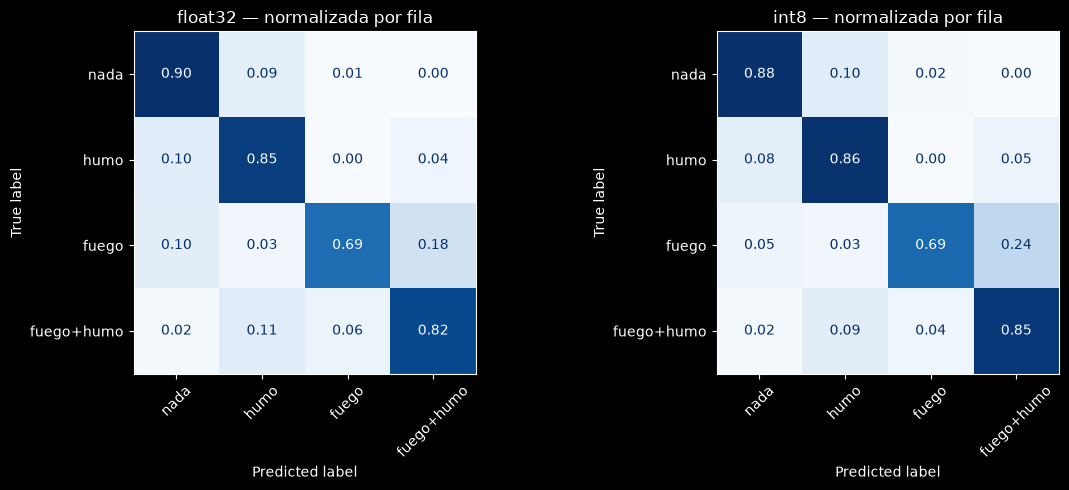

In [10]:
# --- Métricas de la cabeza de imagen: float32 vs int8 ---
print("=== salida de imagen: float32 ===")
print(classification_report(y_true, y_pred, target_names=CLASES, digits=3, zero_division=0))
print("=== salida de imagen: int8 ===")
print(classification_report(y_true, y_pred_int8, target_names=CLASES, digits=3, zero_division=0))

# Matrices de confusión por combinación (4 categorías: nada, humo, fuego, fuego+humo).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (titulo, pred) in zip(axes, [("float32", y_pred), ("int8", y_pred_int8)]):
    cm = confusion_matrix(combo(y_true), combo(pred), labels=range(len(COMBOS)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(
        cm_norm, display_labels=COMBOS,
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{titulo} — normalizada por fila")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# --- Métricas de la grilla: float32 vs int8, por celda ---
# Cada una de las 16 celdas de cada imagen cuenta como un ejemplo.
g_true_flat = g_true.reshape(-1, 2)

print("=== grilla (por celda): float32 ===")
g_pred_f32 = (g_prob >= 0.5).reshape(-1, 2).astype(np.uint8)
r = classification_report(g_true_flat, g_pred_f32, target_names=CLASES, digits=3, zero_division=0)
print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")

print("=== grilla (por celda): int8 ===")
g_pred_int8_flat = (g_prob_int8 >= 0.5).reshape(-1, 2).astype(np.uint8)
r = classification_report(g_true_flat, g_pred_int8_flat, target_names=CLASES, digits=3, zero_division=0)
print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")

# ¿Apunta al lugar correcto? La celda más probable de la red es una celda marcada.
def apunta(sub, titulo, y_t, g_p):
    print(f"=== celda más probable dentro de la etiqueta: {titulo} ===")
    for c, nombre in enumerate(CLASES):
        con = sub[y_t[sub, c] == 1]
        verdad = g_true[con, :, :, c].reshape(len(con), -1)
        mejor = g_p[con, :, :, c].reshape(len(con), -1).argmax(axis=1)
        acierto = verdad[np.arange(len(con)), mejor].mean()
        print(f"{nombre:<6} {acierto:6.1%}   (azar {verdad.mean():5.1%})   {len(con)} imágenes")
    print()


print("--- float32 ---")
apunta(np.arange(len(y_true)), "prueba completa", y_true, g_prob)
print("--- int8 ---")
apunta(np.arange(len(y_true)), "prueba completa", y_true, g_prob_int8)

=== grilla (por celda): float32 ===
              precision    recall  f1-score   support

       fuego      0.578     0.739     0.649      4484
        humo      0.628     0.508     0.562     14191

   micro avg      0.612     0.564     0.587     18675
   macro avg      0.603     0.624     0.605     18675
weighted avg      0.616     0.564     0.583     18675

=== grilla (por celda): int8 ===
              precision    recall  f1-score   support

       fuego      0.540     0.775     0.636      4484
        humo      0.602     0.547     0.573     14191

   micro avg      0.581     0.602     0.591     18675
   macro avg      0.571     0.661     0.605     18675
weighted avg      0.587     0.602     0.588     18675

--- float32 ---
=== celda más probable dentro de la etiqueta: prueba completa ===
fuego   86.9%   (azar 25.1%)   1115 imágenes
humo    76.0%   (azar 42.6%)   2081 imágenes

--- int8 ---
=== celda más probable dentro de la etiqueta: prueba completa ===
fuego   86.4%   (azar 25.

In [12]:
def a_rgb565(imagen):
    '''Color cuantizado a 5/6/5 bits por canal, como lo entrega el OV2640.

    Las imágenes de `test_ds` ya están a 96×96: lo único que falta imitar es la
    profundidad de color del sensor.
    '''
    x = np.clip(np.round(imagen), 0, 255).astype(np.uint16)
    r, g, b = x[..., 0] >> 3, x[..., 1] >> 2, x[..., 2] >> 3      # 5, 6 y 5 bits
    return np.stack([(r << 3) | (r >> 2),                          # 5 bits -> 8
                     (g << 2) | (g >> 4),                          # 6 bits -> 8
                     (b << 3) | (b >> 2)], axis=-1).astype(np.float32)


y_prob_camara, g_prob_camara = evaluar_int8(test_ds, transformar=a_rgb565)
y_pred_camara = (y_prob_camara >= 0.5).astype(np.uint8)
print("=== int8 sobre RGB565, como lo ve la cámara ===")
print("--- salida de imagen ---")
print(classification_report(y_true, y_pred_camara, target_names=CLASES, digits=3, zero_division=0))
print("--- grilla (por celda) ---")
g_pred_camara_flat = (g_prob_camara >= 0.5).reshape(-1, 2).astype(np.uint8)
r = classification_report(g_true_flat, g_pred_camara_flat, target_names=CLASES, digits=3, zero_division=0)
print("\n".join(l for l in r.splitlines() if not l.lstrip().startswith("samples")) + "\n")

=== int8 sobre RGB565, como lo ve la cámara ===
--- salida de imagen ---
              precision    recall  f1-score   support

       fuego      0.908     0.895     0.902      1115
        humo      0.884     0.914     0.898      2081

   micro avg      0.892     0.907     0.899      3196
   macro avg      0.896     0.904     0.900      3196
weighted avg      0.892     0.907     0.899      3196
 samples avg      0.486     0.484     0.480      3196

--- grilla (por celda) ---
              precision    recall  f1-score   support

       fuego      0.557     0.763     0.644      4484
        humo      0.613     0.527     0.567     14191

   micro avg      0.594     0.583     0.589     18675
   macro avg      0.585     0.645     0.605     18675
weighted avg      0.600     0.583     0.585     18675



In [13]:
from sklearn.metrics import precision_score, recall_score

variantes = [("float32 (Keras)", y_pred),
             ("int8 (TFLite)", y_pred_int8),
             ("int8 + RGB565 (cámara)", y_pred_camara)]


def tabla_imagen(titulo, mascara):
    '''Recall y precisión por etiqueta, con el umbral provisorio de 0,5.'''
    print(f"\n{titulo}   ({np.sum(mascara)} imágenes)")
    print(f"{'variante':<26}"
          + "".join(f"{'recall ' + c:>14}{'precisión ' + c:>17}" for c in CLASES))
    for nombre, pred in variantes:
        r = recall_score(y_true[mascara], pred[mascara], average=None, zero_division=0)
        p = precision_score(y_true[mascara], pred[mascara], average=None, zero_division=0)
        print(f"{nombre:<26}"
              + "".join(f"{r[i]:>14.3f}{p[i]:>17.3f}" for i in range(len(CLASES))))


tabla_imagen("prueba completa", np.ones(len(y_true), bool))
# El número que vale: sin los gemelos del entrenamiento (§6bis del notebook 4) no queda nada que
# memorizar, así que acá se ve la generalización de verdad.
tabla_imagen("prueba sin gemelos de entrenamiento", LIMPIO)

# Tabla de grilla por celda, float32 vs int8 vs cámara
variantes_grilla = [("float32 (Keras)", (g_prob >= 0.5).reshape(-1, 2).astype(np.uint8)),
                    ("int8 (TFLite)", (g_prob_int8 >= 0.5).reshape(-1, 2).astype(np.uint8)),
                    ("int8 + RGB565 (cámara)", g_pred_camara_flat)]

print(f"\ngrilla por celda   ({len(g_true_flat)} celdas)")
print(f"{'variante':<26}"
      + "".join(f"{'recall ' + c:>14}{'precisión ' + c:>17}" for c in CLASES))
for nombre, pred in variantes_grilla:
    r = recall_score(g_true_flat, pred, average=None, zero_division=0)
    p = precision_score(g_true_flat, pred, average=None, zero_division=0)
    print(f"{nombre:<26}"
          + "".join(f"{r[i]:>14.3f}{p[i]:>17.3f}" for i in range(len(CLASES))))

print(f"\n.tflite             {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")
print("MACs, arena y latencia estimadas: §4 del notebook 4 "
      "(la arena se confirma en placa con arena_used_bytes())")


prueba completa   (4306 imágenes)
variante                    recall fuego  precisión fuego   recall humo   precisión humo
float32 (Keras)                    0.874            0.928         0.910            0.893
int8 (TFLite)                      0.896            0.902         0.927            0.874
int8 + RGB565 (cámara)             0.895            0.908         0.914            0.884

prueba sin gemelos de entrenamiento   (3320 imágenes)
variante                    recall fuego  precisión fuego   recall humo   precisión humo
float32 (Keras)                    0.867            0.922         0.911            0.897
int8 (TFLite)                      0.888            0.897         0.925            0.878
int8 + RGB565 (cámara)             0.887            0.906         0.915            0.888

grilla por celda   (68896 celdas)
variante                    recall fuego  precisión fuego   recall humo   precisión humo
float32 (Keras)                    0.739            0.578         0.508   

### Umbral de decisión

Hasta acá el umbral fue 0,5 en cada etiqueta: un valor que nadie eligió. Ahora hay **dos
umbrales** independientes:

1. **Umbral de imagen (`umbral_salida`)**: alerta si max(P(`fuego`), P(`humo`)) ≥ umbral.
   Es la misma regla del notebook 5. Se elige en validación sin gemelos con el modelo
   desplegado (int8 + RGB565), fijando la fracción máxima de eventos perdidos.
2. **Umbral de grilla (`umbral_grilla`)**: la celda se activa si P(clase) ≥ umbral. Se
   elige en validación sin gemelos, maximizando el umbral que no pierda más de
   `OBJETIVO_PERDIDAS_GRILLA` de las *celdas* positivas (recall ≥ 1 − objetivo).

Los dos se eligen en **validación sin gemelos**, con el modelo desplegado (int8 + RGB565).
Los dos viajan al firmware en `cuantizacion_grilla.json`, ya convertidos a int8.

Cuatro cuidados:

- **Se elige en validación y se mide en prueba.** Elegirlo mirando la prueba es ajustarlo
  a los mismos datos con los que después se lo evalúa.
- **Se elige sobre la validación sin gemelos.** Validación también tiene gemelos de
  entrenamiento (§6bis del notebook 4); con ellos adentro las pérdidas se subestiman y el
  umbral queda corto.
- **Se elige con el modelo desplegado** (int8 + RGB565), no con el float: es su salida la
  que el firmware va a comparar.
- **Viaja al firmware** en `cuantizacion_grilla.json`, ya convertido a int8: el nodo
  compara la salida cruda sin decuantizar.

In [14]:
# Regla del nodo: alerta si max(P(fuego), P(humo)) >= UMBRAL. Se elige en VALIDACIÓN
# sin gemelos y con el modelo desplegado (int8 + RGB565); la prueba sólo la mide.
OBJETIVO_PERDIDAS = 0.05             # imagen: fracción de eventos que se tolera perder
OBJETIVO_PERDIDAS_GRILLA = 0.10      # grilla: fracción de celdas positivas que se tolera perder

# --- Umbral de imagen (igual que en el notebook 5) ---
p_val_salida, p_val_grilla = evaluar_int8(val_ds, transformar=a_rgb565)
p_val_img = p_val_salida.max(axis=1)
evento_val = ETIQUETAS[idx_val].any(axis=1)

candidatos = np.linspace(0, 1, 201)
perdidas_val = np.array([np.mean(p_val_img[evento_val & LIMPIO_VAL] < u) for u in candidatos])
falsas_val = np.array([np.mean(p_val_img[~evento_val & LIMPIO_VAL] >= u) for u in candidatos])
cumple = perdidas_val <= OBJETIVO_PERDIDAS
k = np.flatnonzero(cumple)[-1]
UMBRAL_SALIDA = float(candidatos[k])
print(f"imagen: umbral {UMBRAL_SALIDA:.3f} -> pierde {perdidas_val[k]:.1%} de los "
      f"eventos, falsa alarma en {falsas_val[k]:.1%} de las escenas sin evento")

# --- Umbral de grilla (nuevo) ---
# Etiquetas por celda de validación, sin aumento.
g_true_val = GRILLAS[idx_val]
g_true_val_limpio = g_true_val[LIMPIO_VAL].reshape(-1, 2)
g_prob_val_limpio = p_val_grilla[LIMPIO_VAL].reshape(-1, 2)

# Celdas perdidas en función del umbral, POR ETIQUETA y quedándose con la peor. Mirar
# el máximo sobre las dos etiquetas (`max(axis=1)`) daría por detectada una celda que sólo
# tiene humo porque su P(fuego) es alta, y el umbral saldría más alto de lo que corresponde.
candidatos_g = np.linspace(0, 1, 201)
perdidas_grilla_val = np.array([
    max(np.mean(g_prob_val_limpio[g_true_val_limpio[:, c] == 1, c] < u)
        for c in range(len(CLASES)))
    for u in candidatos_g
])
cumple_g = perdidas_grilla_val <= OBJETIVO_PERDIDAS_GRILLA
k_g = np.flatnonzero(cumple_g)[-1]
UMBRAL_GRILLA = float(candidatos_g[k_g])
print(f"grilla: umbral {UMBRAL_GRILLA:.3f} -> pierde {perdidas_grilla_val[k_g]:.1%} de las "
      f"celdas positivas\n")

# --- Medición en prueba ---
p_test_img = y_prob_camara.max(axis=1)
fuego = (y_true[:, 0] == 1) & LIMPIO
evento = y_true.any(axis=1) & LIMPIO
sin_evento = ~y_true.any(axis=1) & LIMPIO
print("prueba sin gemelos, int8 + RGB565 (imagen):")
print(f"{'regla':<16}{'evento sin alerta':>19}{'fuego sin alerta':>18}"
      f"{'fuego sólo como humo':>22}{'falsa alarma':>14}")
for nombre, u in [("umbral 0,5", 0.5), (f"umbral {UMBRAL_SALIDA:.3f}", UMBRAL_SALIDA)]:
    alerta = p_test_img >= u
    solo_humo = alerta & (y_prob_camara[:, 0] < u)
    print(f"{nombre:<16}{np.mean(~alerta[evento]):>19.1%}{np.mean(~alerta[fuego]):>18.1%}"
          f"{np.mean(solo_humo[fuego]):>22.1%}{np.mean(alerta[sin_evento]):>14.1%}")

# Medición de la grilla en prueba
g_true_flat_limpio = g_true[LIMPIO].reshape(-1, 2)
g_prob_camara_flat_limpio = g_prob_camara[LIMPIO].reshape(-1, 2)
for nombre, u in [("umbral 0,5", 0.5), (f"umbral {UMBRAL_GRILLA:.3f}", UMBRAL_GRILLA)]:
    g_pred_u = (g_prob_camara_flat_limpio >= u).astype(np.uint8)
    r = recall_score(g_true_flat_limpio, g_pred_u, average=None, zero_division=0)
    p = precision_score(g_true_flat_limpio, g_pred_u, average=None, zero_division=0)
    print(f"\ngrilla sin gemelos ({nombre}):  "
          + "  ".join(f"{c}: recall {r[i]:.3f}  precisión {p[i]:.3f}" for i, c in enumerate(CLASES)))

# --- Convertir umbrales a int8 y guardar en el JSON ---
# Las dos etiquetas de 'salida' comparten tensor, o sea la misma escala y zero_point:
# p >= u  <=>  q >= u / escala + zero_point  <=>  q >= ceil(u / escala + zero_point).
escala_s, zp_s = det_salida["quantization"]
escala_g, zp_g = det_grilla["quantization"]

cuantizacion["decision"] = {
    "regla_imagen": "alerta si max(salida_int8[0], salida_int8[1]) >= umbral_salida_int8",
    "umbral_salida": UMBRAL_SALIDA,
    "umbral_salida_int8": int(np.ceil(UMBRAL_SALIDA / escala_s + zp_s)),
    "objetivo_perdidas_imagen": OBJETIVO_PERDIDAS,
    "regla_grilla": "celda activa si grilla_int8[fila][col][c] >= umbral_grilla_int8",
    "umbral_grilla": UMBRAL_GRILLA,
    "umbral_grilla_int8": int(np.ceil(UMBRAL_GRILLA / escala_g + zp_g)),
    "objetivo_perdidas_grilla": OBJETIVO_PERDIDAS_GRILLA,
}
(ruta_modelos / "cuantizacion_grilla.json").write_text(json.dumps(cuantizacion, indent=2))
print(f"\n{ruta_modelos / 'cuantizacion_grilla.json'}: {json.dumps(cuantizacion['decision'], indent=2)}")

imagen: umbral 0.525 -> pierde 5.0% de los eventos, falsa alarma en 10.6% de las escenas sin evento
grilla: umbral 0.140 -> pierde 9.8% de las celdas positivas

prueba sin gemelos, int8 + RGB565 (imagen):
regla             evento sin alerta  fuego sin alerta  fuego sólo como humo  falsa alarma
umbral 0,5                     6.2%              2.2%                  9.1%         12.2%
umbral 0.525                   6.5%              2.3%                  9.6%         11.5%

grilla sin gemelos (umbral 0,5):  fuego: recall 0.759  precisión 0.564  humo: recall 0.541  precisión 0.629

grilla sin gemelos (umbral 0.140):  fuego: recall 0.913  precisión 0.330  humo: recall 0.932  precisión 0.369

../salidas/modelos/cuantizacion_grilla.json: {
  "regla_imagen": "alerta si max(salida_int8[0], salida_int8[1]) >= umbral_salida_int8",
  "umbral_salida": 0.525,
  "umbral_salida_int8": 7,
  "objetivo_perdidas_imagen": 0.05,
  "regla_grilla": "celda activa si grilla_int8[fila][col][c] >= umbral_grilla_i

## 4. Entregables

| Archivo | Qué es |
|---|---|
| `salidas/modelos/grilla_int8.cc` | el modelo int8 como array de C (`const`, `alignas(16)`): es lo que se compila en el firmware |
| `salidas/modelos/grilla_int8.tflite` | el mismo modelo, para volver a medirlo sin regenerarlo |
| `salidas/modelos/cuantizacion_grilla.json` | escala y `zero_point` de entrada, salida de imagen **y** salida de grilla (cada una con su propia escala), y la **regla de decisión**: umbral de imagen y umbral de grilla, ambos ya convertidos a int8 |

El `.keras` que entró es un *checkpoint* del entrenamiento, no un entregable. Las ops a
registrar en el `MicroMutableOpResolver` salen de §2; el reparto de memoria (flash / SRAM
interna / PSRAM), del §4 del notebook 4.

In [15]:
(ruta_modelos / "grilla_int8.tflite").write_bytes(tflite)

for ruta in sorted(ruta_modelos.iterdir()):
    print(f"{ruta.name:<45}{ruta.stat().st_size / 1024:>9.1f} kB")

cnn_fuego_epochs_82_image_size_96x96.keras      1176.8 kB
cuantizacion.json                                  0.5 kB
cuantizacion_grilla.json                           0.8 kB
grilla4x4_fuego_epochs_84_image_size_96x96.keras   3821.1 kB
grilla_int8.cc                                  1989.2 kB
grilla_int8.tflite                               314.0 kB
modelo_int8.cc                                  1954.2 kB
modelo_int8.tflite                               308.5 kB
v1                                                 0.2 kB


## 5. Conclusiones

- **El `.tflite` tiene dos tensores de salida** (`salida` y `grilla`), cada uno con su
  propia escala y *zero point*. El firmware tiene que leer los dos y aplicar el umbral
  correspondiente.
- **La métrica de despliegue sigue siendo la alerta de imagen**, no el recall por etiqueta.
  Un incendio visto sólo como humo no pierde la alerta; uno en el que no se enciende
  ninguna salida, sí. §3 separa los dos, y el umbral de decisión se fija contra ese
  objetivo.
- **La grilla agrega información de *dónde***, empaquetada en 4 bytes por imagen (16
  celdas × 2 bits). El umbral por celda se elige con un objetivo separado, porque la
  grilla está mucho más desbalanceada que la imagen (menos del 10 % de las celdas es
  positiva).
- **La caída de float a int8 se tiene que mirar en las dos salidas.** Si la grilla pierde
  mucho más que la imagen, puede ser que las celdas de la cabeza de grilla necesiten
  más calibración (subir `N_REPRESENTATIVAS`) o un α más grande.
- **Cuantización PTQ**, no QAT: las mismas palancas que el notebook 5 (más representativas,
  α=0.5, inspeccionar qué capa concentra el error).